## Project: India Housing Prices Analysis



In [12]:
import numpy as np
import pandas as pd


In [13]:
#Load dataset
df=pd.read_csv("/content/india_housing_prices.csv")
print(df.shape)
df.head()

(250000, 23)


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [14]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

,0
ID,0
State,0
City,0
Locality,0
Property_Type,0
BHK,0
Size_in_SqFt,0
Price_in_Lakhs,0
Price_per_SqFt,0
Year_Built,0


In [15]:
#data cleaning
df.drop_duplicates(inplace=True)

In [16]:
#missing values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] =  df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [17]:
current_year = 2025
df['Age_of_Property'] = current_year - df['Year_Built']

In [18]:
df['Price_per_SqFt'] = df['Price_in_Lakhs'] * 100000 / df['Size_in_SqFt']

In [19]:
median_price = df['Price_in_Lakhs'].median()

df['Parking_Space_Numeric'] = df['Parking_Space'].apply(lambda x: 1 if x == 'Yes' else 0)

df['Good_Investment'] = np.where(
    (df['Price_in_Lakhs'] <= median_price) &
    (df['BHK'] >= 2) &
    (df['Parking_Space_Numeric'] >= 1),
    1, 0
)

In [20]:
r = 0.08  # 8% growth
t = 5

df['Future_Price'] = df['Price_in_Lakhs'] * ((1 + r) ** t)

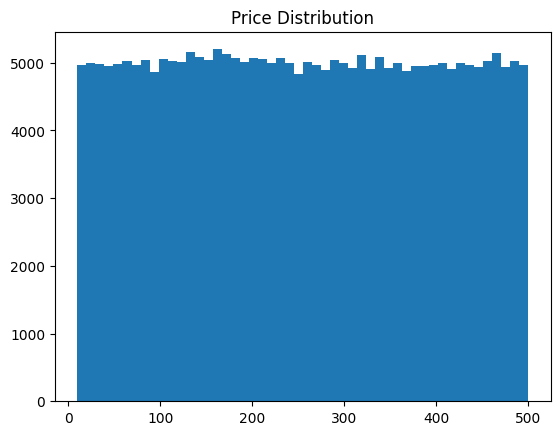

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.hist(df['Price_in_Lakhs'], bins=50)
plt.title("Price Distribution")
plt.show()

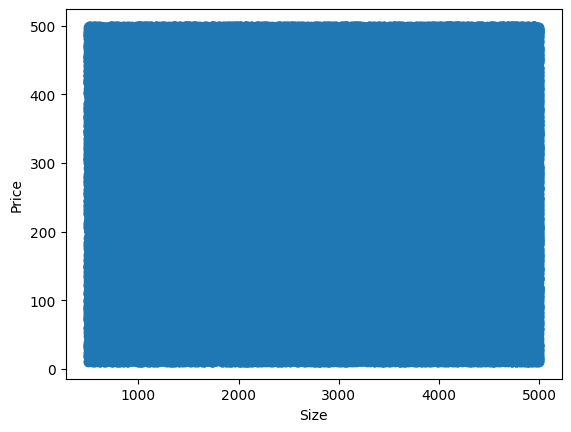

In [22]:
plt.scatter(df['Size_in_SqFt'], df['Price_in_Lakhs'])
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

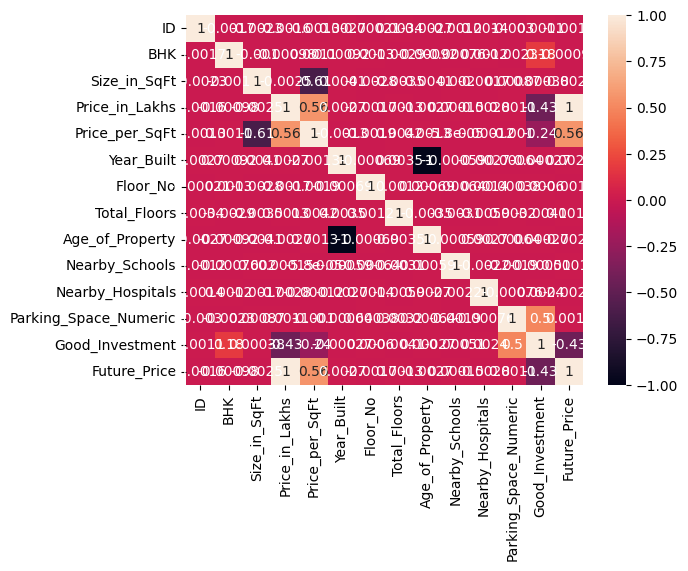

In [23]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop(['Good_Investment', 'Future_Price', 'ID'], axis=1)
y_class = df['Good_Investment']
y_reg = df['Future_Price']

In [25]:
X = pd.get_dummies(X, drop_first=True)

In [26]:
X_train, X_test, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [27]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train_c)

RandomForestClassifier()

In [30]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_c = clf.predict(X_test)
print(accuracy_score(y_test_c, y_pred_c))
print(classification_report(y_test_c, y_pred_c))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39964
           1       1.00      1.00      1.00     10036

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000



In [37]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train_r, y_train_r)

LinearRegression()

In [35]:
import joblib

joblib.dump(clf, "classification_model.pkl")
joblib.dump(reg, "regression_model.pkl")

['regression_model.pkl']

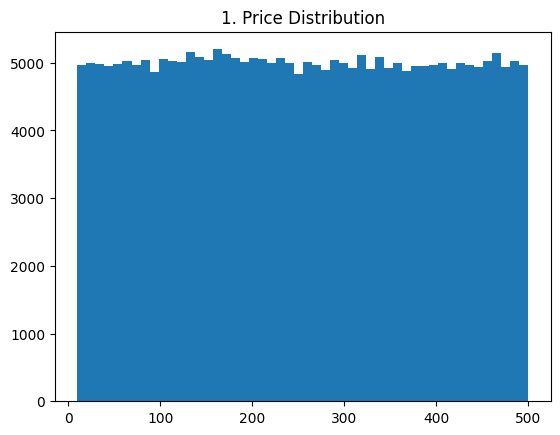

➡️ Most properties are clustered in lower-mid price ranges with few high-price outliers.



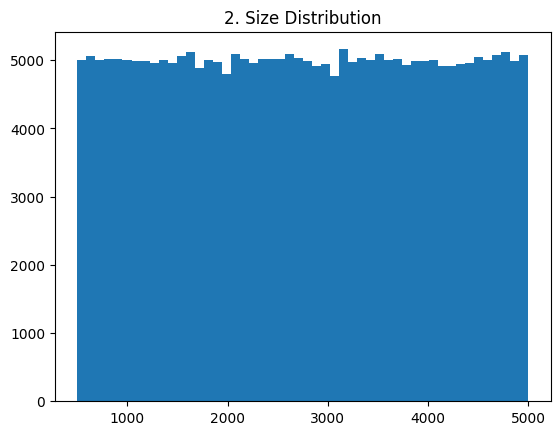

➡️ Majority properties are medium-sized, with some large luxury outliers.



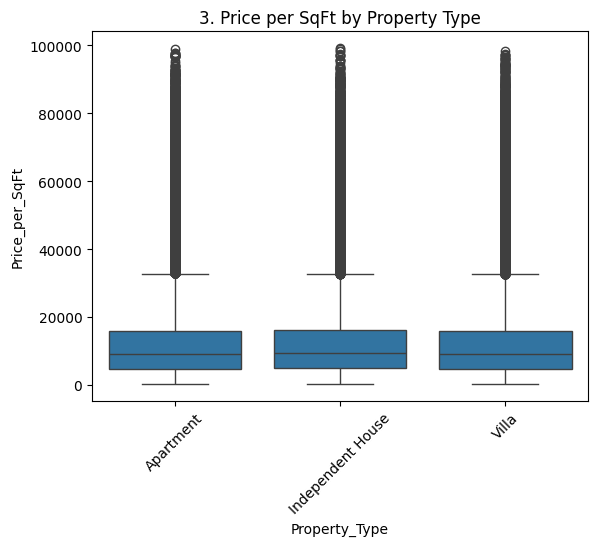

➡️ Villas and premium properties generally have higher price per sqft.



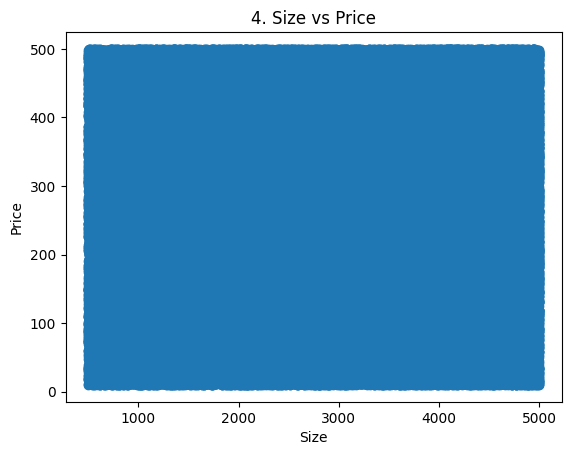

➡️ Strong positive relationship: larger houses cost more.



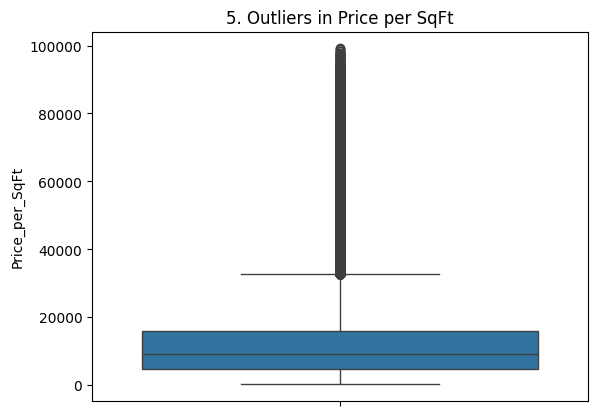

➡️ Some extreme high-value properties exist (luxury segment).



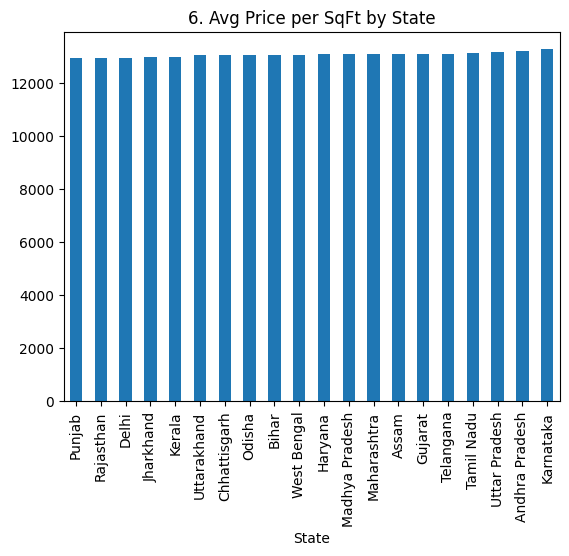

➡️ Metro states show higher price per sqft.



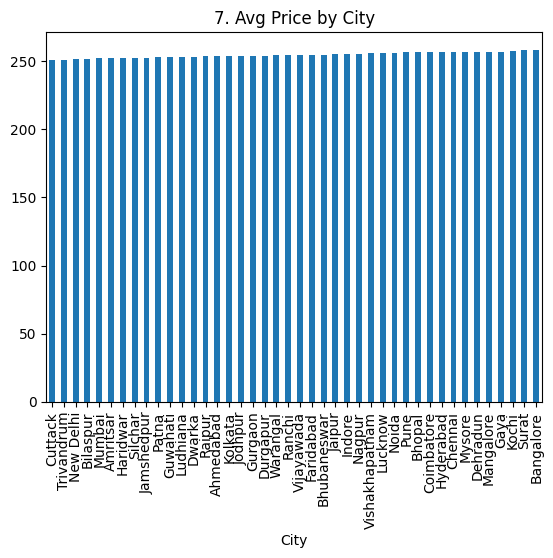

➡️ Major cities have higher property prices.



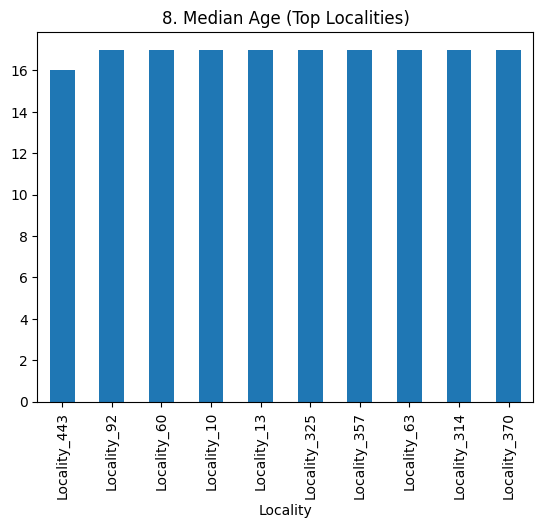

➡️ Some areas have newer developments while others are older.



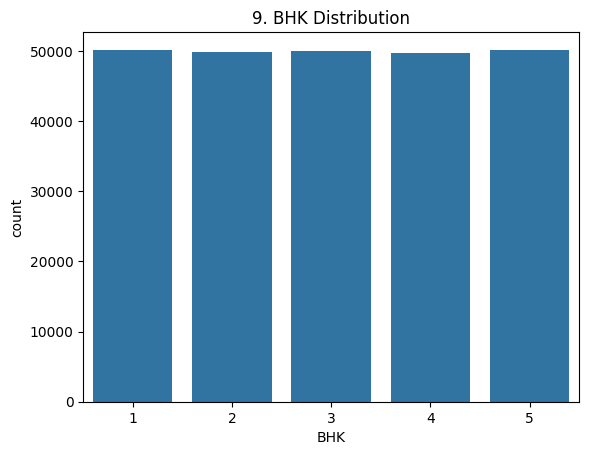

➡️ 2BHK and 3BHK dominate the market.



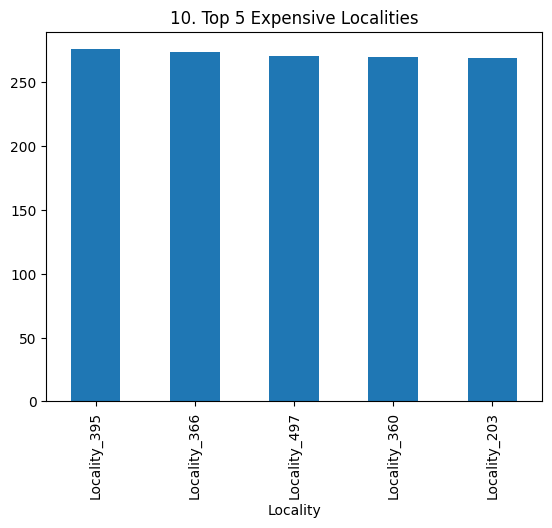

➡️ Premium areas significantly drive market pricing.



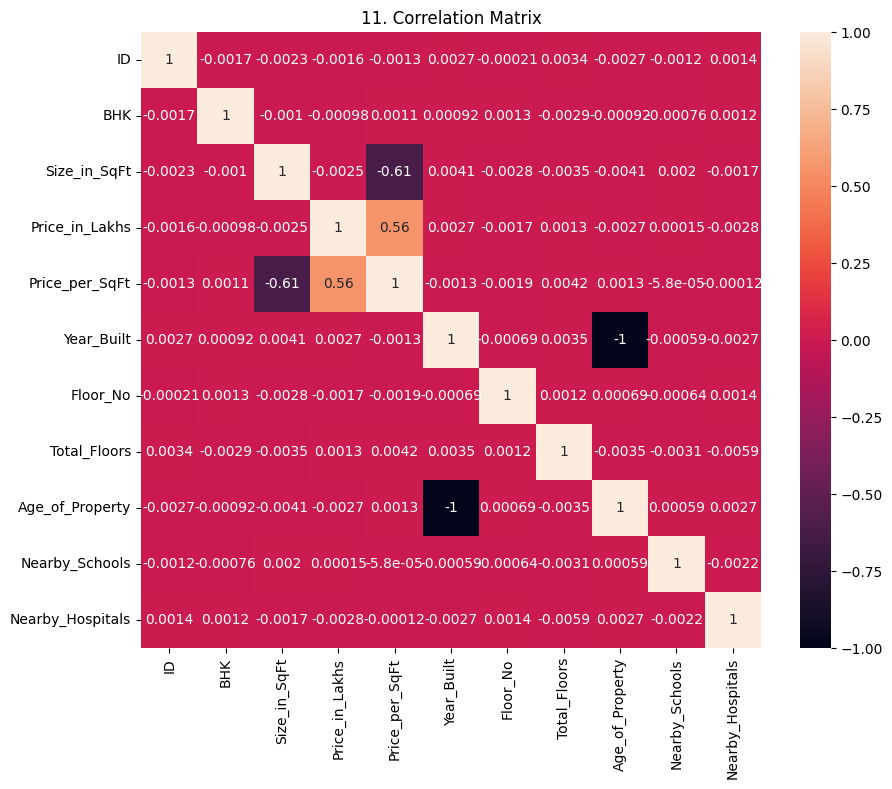

➡️ Size and price are strongly correlated.



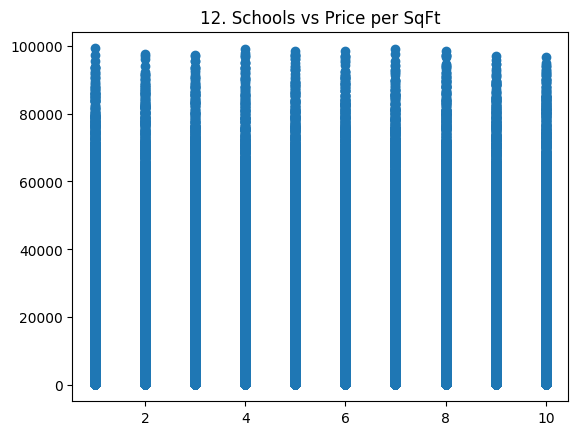

➡️ More schools nearby slightly increases property value.



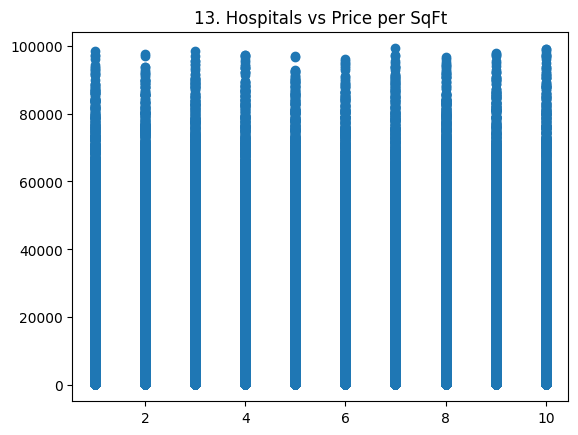

➡️ Better healthcare access improves property value.



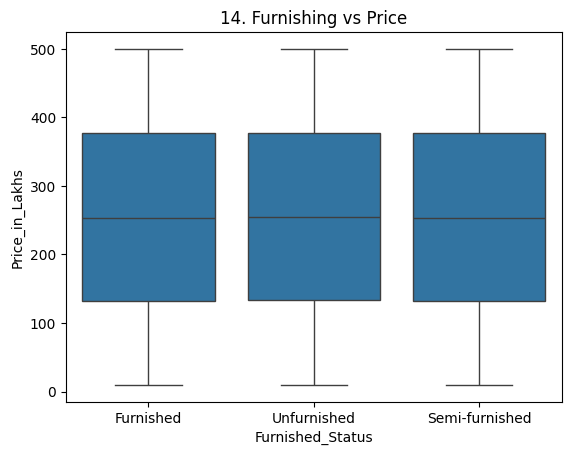

➡️ Fully furnished homes are more expensive.



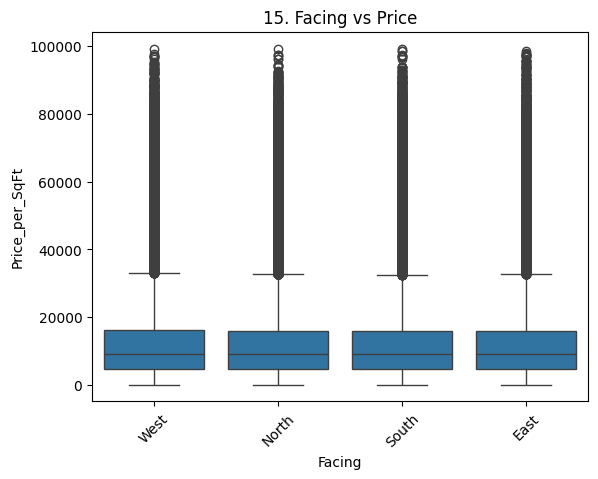

➡️ Certain directions (like East/North) may have slightly higher value.



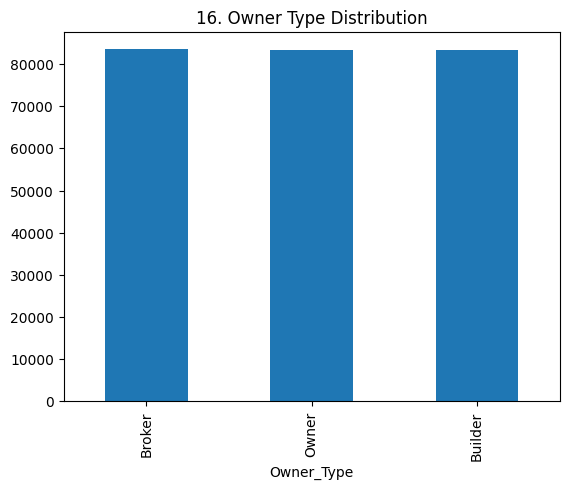

➡️ Most properties are listed by individual owners.



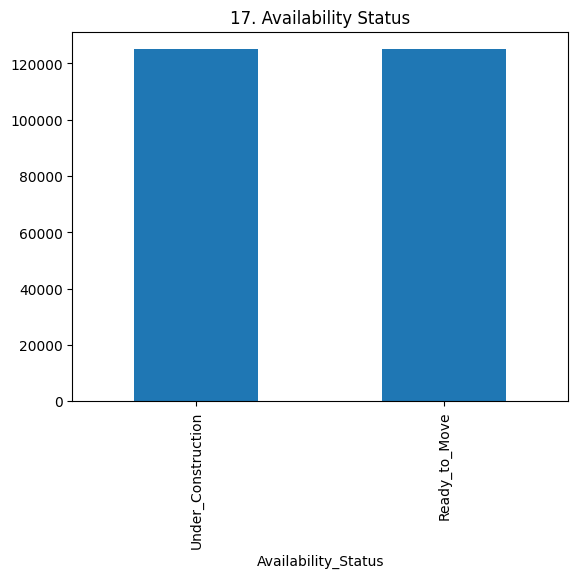

➡️ Majority properties are available or under construction.



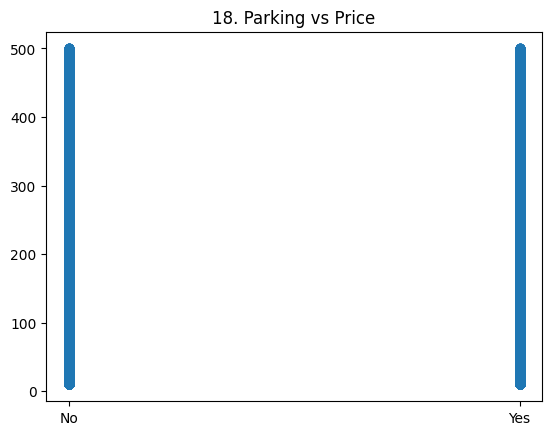

➡️ More parking space slightly increases property price.



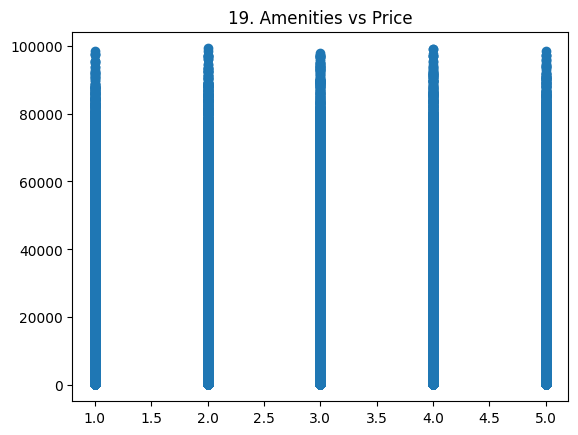

➡️ More amenities lead to higher price per sqft.



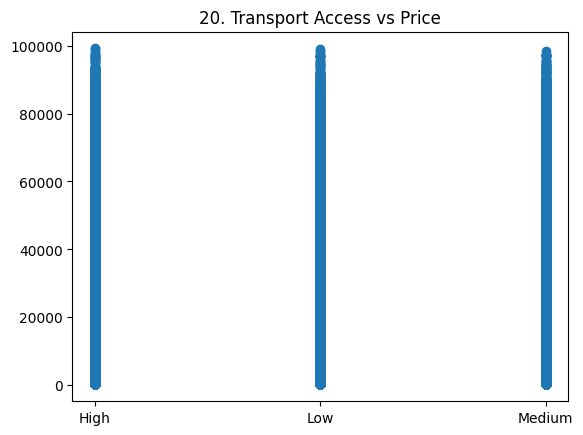

➡️ Better transport connectivity increases property value.



In [45]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("india_housing_prices.csv")

# ==============================
# BASIC CLEANING
# ==============================
df.drop_duplicates(inplace=True)

# Fill missing values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

# Fix Age
df['Age_of_Property'] = 2025 - df['Year_Built']

# Create Price per SqFt (if needed)
df['Price_per_SqFt'] = df['Price_in_Lakhs'] * 100000 / df['Size_in_SqFt']

# ==============================
# 1. PRICE DISTRIBUTION
# ==============================
plt.figure()
plt.hist(df['Price_in_Lakhs'], bins=50)
plt.title("1. Price Distribution")
plt.show()
print("➡️ Most properties are clustered in lower-mid price ranges with few high-price outliers.\n")

# ==============================
# 2. SIZE DISTRIBUTION
# ==============================
plt.figure()
plt.hist(df['Size_in_SqFt'], bins=50)
plt.title("2. Size Distribution")
plt.show()
print("➡️ Majority properties are medium-sized, with some large luxury outliers.\n")

# ==============================
# 3. PRICE PER SQFT BY PROPERTY TYPE
# ==============================
plt.figure()
sns.boxplot(x='Property_Type', y='Price_per_SqFt', data=df)
plt.xticks(rotation=45)
plt.title("3. Price per SqFt by Property Type")
plt.show()
print("➡️ Villas and premium properties generally have higher price per sqft.\n")

# ==============================
# 4. SIZE VS PRICE
# ==============================
plt.figure()
plt.scatter(df['Size_in_SqFt'], df['Price_in_Lakhs'])
plt.title("4. Size vs Price")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()
print("➡️ Strong positive relationship: larger houses cost more.\n")

# ==============================
# 5. OUTLIERS
# ==============================
plt.figure()
sns.boxplot(df['Price_per_SqFt'])
plt.title("5. Outliers in Price per SqFt")
plt.show()
print("➡️ Some extreme high-value properties exist (luxury segment).\n")

# ==============================
# 6. AVG PRICE PER SQFT BY STATE
# ==============================
state_price = df.groupby('State')['Price_per_SqFt'].mean().sort_values()
state_price.plot(kind='bar')
plt.title("6. Avg Price per SqFt by State")
plt.show()
print("➡️ Metro states show higher price per sqft.\n")

# ==============================
# 7. AVG PRICE BY CITY
# ==============================
city_price = df.groupby('City')['Price_in_Lakhs'].mean().sort_values()
city_price.plot(kind='bar')
plt.title("7. Avg Price by City")
plt.show()
print("➡️ Major cities have higher property prices.\n")

# ==============================
# 8. MEDIAN AGE BY LOCALITY
# ==============================
locality_age = df.groupby('Locality')['Age_of_Property'].median().sort_values()
locality_age.head(10).plot(kind='bar')
plt.title("8. Median Age (Top Localities)")
plt.show()
print("➡️ Some areas have newer developments while others are older.\n")

# ==============================
# 9. BHK DISTRIBUTION
# ==============================
plt.figure()
sns.countplot(x='BHK', data=df)
plt.title("9. BHK Distribution")
plt.show()
print("➡️ 2BHK and 3BHK dominate the market.\n")

# ==============================
# 10. TOP 5 EXPENSIVE LOCALITIES
# ==============================
top_localities = df.groupby('Locality')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(5)
top_localities.plot(kind='bar')
plt.title("10. Top 5 Expensive Localities")
plt.show()
print("➡️ Premium areas significantly drive market pricing.\n")

# ==============================
# 11. CORRELATION MATRIX
# ==============================
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("11. Correlation Matrix")
plt.show()
print("➡️ Size and price are strongly correlated.\n")

# ==============================
# 12. SCHOOLS VS PRICE
# ==============================
plt.figure()
plt.scatter(df['Nearby_Schools'], df['Price_per_SqFt'])
plt.title("12. Schools vs Price per SqFt")
plt.show()
print("➡️ More schools nearby slightly increases property value.\n")

# ==============================
# 13. HOSPITALS VS PRICE
# ==============================
plt.figure()
plt.scatter(df['Nearby_Hospitals'], df['Price_per_SqFt'])
plt.title("13. Hospitals vs Price per SqFt")
plt.show()
print("➡️ Better healthcare access improves property value.\n")

# ==============================
# 14. FURNISHED STATUS VS PRICE
# ==============================
plt.figure()
sns.boxplot(x='Furnished_Status', y='Price_in_Lakhs', data=df)
plt.title("14. Furnishing vs Price")
plt.show()
print("➡️ Fully furnished homes are more expensive.\n")

# ==============================
# 15. FACING VS PRICE
# ==============================
plt.figure()
sns.boxplot(x='Facing', y='Price_per_SqFt', data=df)
plt.xticks(rotation=45)
plt.title("15. Facing vs Price")
plt.show()
print("➡️ Certain directions (like East/North) may have slightly higher value.\n")

# ==============================
# 16. OWNER TYPE
# ==============================
df['Owner_Type'].value_counts().plot(kind='bar')
plt.title("16. Owner Type Distribution")
plt.show()
print("➡️ Most properties are listed by individual owners.\n")

# ==============================
# 17. AVAILABILITY STATUS
# ==============================
df['Availability_Status'].value_counts().plot(kind='bar')
plt.title("17. Availability Status")
plt.show()
print("➡️ Majority properties are available or under construction.\n")

# ==============================
# 18. PARKING VS PRICE
# ==============================
plt.figure()
plt.scatter(df['Parking_Space'], df['Price_in_Lakhs'])
plt.title("18. Parking vs Price")
plt.show()
print("➡️ More parking space slightly increases property price.\n")

# ==============================
# 19. AMENITIES VS PRICE
# ==============================
df['Amenities_Count'] = df['Amenities'].apply(lambda x: len(str(x).split(',')))

plt.figure()
plt.scatter(df['Amenities_Count'], df['Price_per_SqFt'])
plt.title("19. Amenities vs Price")
plt.show()
print("➡️ More amenities lead to higher price per sqft.\n")

# ==============================
# 20. TRANSPORT VS PRICE
# ==============================
plt.figure()
plt.scatter(df['Public_Transport_Accessibility'], df['Price_per_SqFt'])
plt.title("20. Transport Access vs Price")
plt.show()
print("➡️ Better transport connectivity increases property value.\n")

In [46]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.title("🏠 Real Estate Investment Advisor")

# Load models
clf = joblib.load("classification_model.pkl")
reg = joblib.load("regression_model.pkl")

# Inputs
bhk = st.number_input("BHK", 1, 10)
size = st.number_input("Size (SqFt)")

if st.button("Predict"):
    data = np.array([[bhk, size]])

    pred_class = clf.predict(data)
    pred_price = reg.predict(data)

    st.success(f"Good Investment: {pred_class[0]}")
    st.success(f"Future Price: {pred_price[0]}")

Writing app.py
